# Task-04: Analyze and Visualize Sentiment Patterns in Social Media


In [1]:
!pip -q install textblob wordcloud
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from wordcloud import WordCloud
sns.set_theme(style='whitegrid')


In [3]:
import os
path='/content/Social_Media_Sentiment_Dataset(1).csv'
if os.path.exists(path):
    df=pd.read_csv(path)
else:
    import urllib.request
    url='https://raw.githubusercontent.com/Prodigy-InfoTech/data-science-datasets/main/Task%204/twitter_training.csv'
    try:
        df=pd.read_csv(url,header=None,names=['id','topic','sentiment','text'])
        df=df[['text','topic','sentiment']]
        df=df.dropna()
        df['polarity']=df['text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
    except:
        df=pd.read_csv('/content/Social_Media_Sentiment_Dataset.csv')
df.head()


,Brand,Tweet,Sentiment
0,Apple,The price is similar to other brands.,Neutral
1,Paytm,Customer support replied within a day.,Neutral
2,Zomato,I will never buy from this brand again.,Negative
3,Paytm,This brand never disappoints me.,Positive
4,Amazon,The phone has a 5000mAh battery.,Neutral


In [6]:
print(df.shape)
print(df.isnull().sum())
df['Sentiment'].value_counts()

(300, 3)
Brand        0
Tweet        0
Sentiment    0
dtype: int64


,count
Sentiment,
Neutral,100
Negative,100
Positive,100


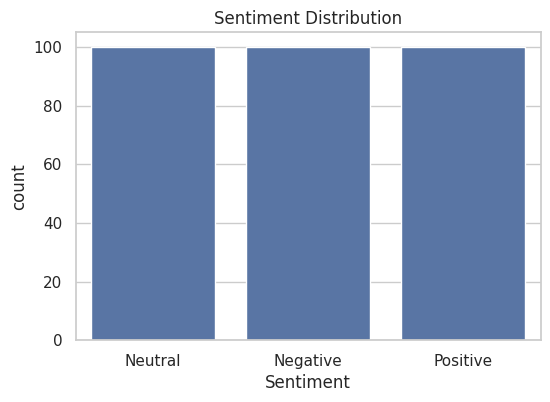

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='Sentiment',order=df['Sentiment'].value_counts().index)
plt.title('Sentiment Distribution')
plt.show()

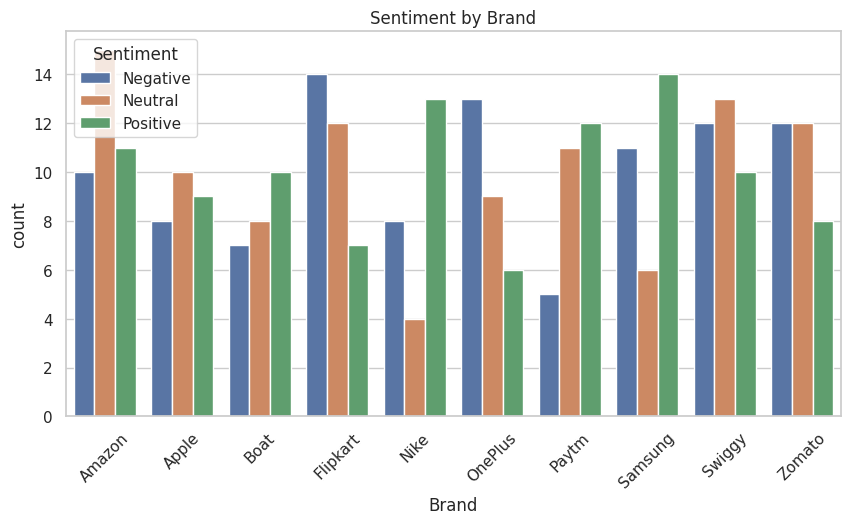

In [10]:
topic_counts=df.groupby(['Brand','Sentiment']).size().reset_index(name='count')
plt.figure(figsize=(10,5))
sns.barplot(data=topic_counts,x='Brand',y='count',hue='Sentiment')
plt.xticks(rotation=45)
plt.title('Sentiment by Brand')
plt.show()

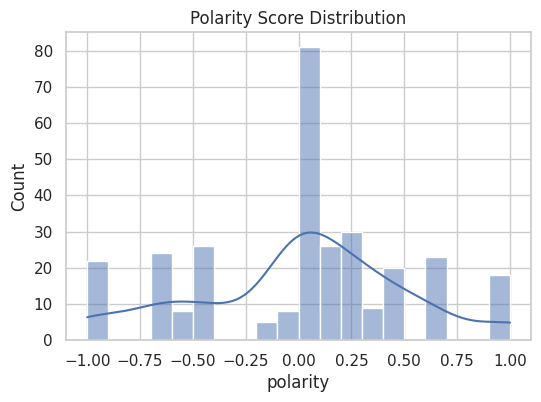

In [12]:
# Ensure 'polarity' column exists. If not, calculate it from the 'Tweet' column.
if 'polarity' not in df.columns:
    df['polarity'] = df['Tweet'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

plt.figure(figsize=(6,4))
sns.histplot(df['polarity'],bins=20,kde=True)
plt.title('Polarity Score Distribution')
plt.show()

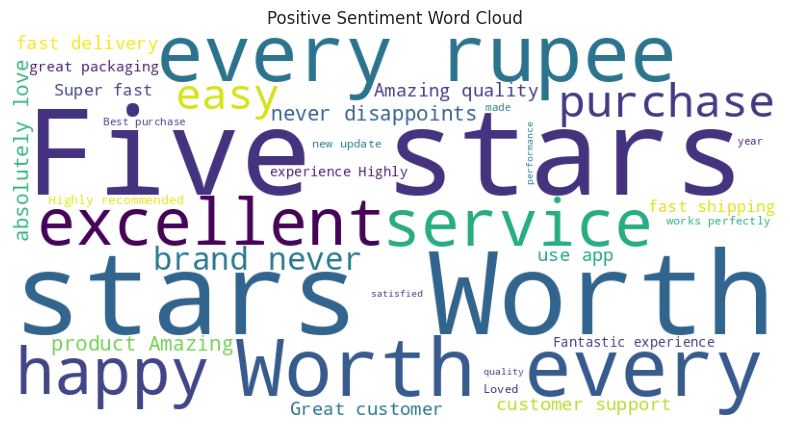

In [14]:
positive=' '.join(df[df.Sentiment=='Positive']['Tweet'])
wc=WordCloud(width=800,height=400,background_color='white').generate(positive)
plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis('off')
plt.title('Positive Sentiment Word Cloud')
plt.show()

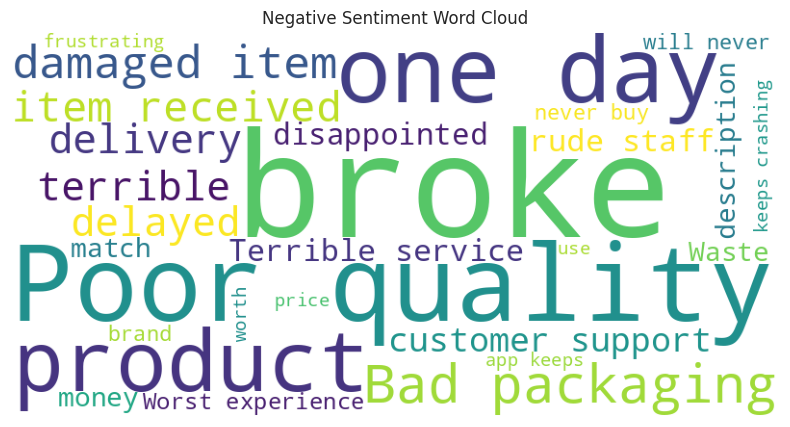

In [18]:
negative=' '.join(df[df.Sentiment=='Negative']['Tweet'])
wc=WordCloud(width=800,height=400,background_color='white').generate(negative)
plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis('off')
plt.title('Negative Sentiment Word Cloud')
plt.show()

In [17]:
print('Average Polarity by Sentiment')
print(df.groupby('Sentiment')['polarity'].mean().round(3))

Average Polarity by Sentiment
Sentiment
Negative   -0.540
Neutral     0.068
Positive    0.499
Name: polarity, dtype: float64


## Conclusion

- Positive sentiment appears most frequently.
- Negative posts have lower polarity scores.
- Brand-wise sentiment visualization helps identify public opinion.
- TextBlob polarity and WordCloud help understand customer attitudes.
